# Homework 10b — Time-Series Forecasting Pipeline

**Track:** Regression forecast  
**Project:** AAPL next-day volatility forecasting  
**Target:** next trading day's absolute adjusted-close return

In the lecture, we learned how to create lag/rolling features, build pipelines, and evaluate with appropriate metrics. Here I adapt those patterns to my project data to build a time-aware next-step forecasting baseline.

In [1]:
# Reproducible imports and repository discovery
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'project' / 'data' / 'processed').exists():
    ROOT = ROOT.parent
if not (ROOT / 'project' / 'data' / 'processed').exists():
    raise FileNotFoundError('Run this notebook from inside the bootcamp_zizhe_zhou repository.')

PROJECT_DIR = ROOT / 'project'
RANDOM_SEED = 7  # Ridge and chronological splits are deterministic; seed is documented for extensions.
np.random.seed(RANDOM_SEED)
sns.set_theme(style='whitegrid', context='notebook')
print('Repository root:', ROOT)

/Users/kevin/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /var/folders/hx/wzbpnq8x7bzb6dg2sz74gg100000gn/T/matplotlib-a7n2ls7u because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


Repository root: /Users/kevin/Desktop/NYU/bootcamp/bootcamp_zizhe_zhou


## 1. Load the cleaned time series

I start from the project's cleaned OHLCV Parquet rather than the pre-engineered model table so this notebook demonstrates every required lag and rolling calculation. Dates are sorted and used as the time index for auditing.

In [2]:
clean_files = sorted((PROJECT_DIR / 'data' / 'processed').glob('aapl_ohlcv_clean_*.parquet'))
if len(clean_files) != 1:
    raise RuntimeError(f'Expected one cleaned OHLCV file, found: {clean_files}')

data_path = clean_files[0]
market = pd.read_parquet(data_path).sort_values('date').reset_index(drop=True)
market['date'] = pd.to_datetime(market['date'])
assert market['date'].is_monotonic_increasing and market['date'].is_unique
print('Data file:', data_path.relative_to(ROOT))
print('Shape:', market.shape)
print('Date range:', market['date'].min().date(), 'to', market['date'].max().date())
market.set_index('date')[['adj_close', 'volume']].head()

Data file: project/data/processed/aapl_ohlcv_clean_20200102_20260824.parquet
Shape: (1669, 9)
Date range: 2020-01-02 to 2026-08-24


,adj_close,volume
date,,
2020-01-02,72.271545,135480400
2020-01-03,71.568909,146322800
2020-01-06,72.139191,118387200
2020-01-07,71.799934,108872000
2020-01-08,72.954910,132079200


## 2. Engineer leakage-safe lag and rolling features

For a forecast made after market close on date *t*, every feature below uses information from *t* or earlier. The target alone uses the absolute return from *t+1*. Rolling windows include the current known observation, require a complete history, and are never backfilled.

New feature families include `lag_k`, rolling mean, rolling standard deviation, momentum, z-score, normalized range, and relative volume—well beyond the minimum requirement of two.

In [3]:
features = market.copy()
daily_return = features['adj_close'].pct_change(fill_method=None)

# Current and lagged return information available by close t
features['return_1d'] = daily_return
features['abs_return_1d'] = daily_return.abs()
features['return_lag_1'] = daily_return.shift(1)
features['return_lag_5'] = daily_return.shift(5)

# Trailing summaries use only rows up through t
features['rolling_mean_5'] = daily_return.rolling(5, min_periods=5).mean()
features['rolling_std_5'] = daily_return.rolling(5, min_periods=5).std()
features['rolling_std_21'] = daily_return.rolling(21, min_periods=21).std()
features['momentum_5'] = features['adj_close'] / features['adj_close'].shift(5) - 1
rolling_mean_20 = daily_return.rolling(20, min_periods=20).mean()
rolling_std_20 = daily_return.rolling(20, min_periods=20).std()
features['return_zscore_20'] = (daily_return - rolling_mean_20) / rolling_std_20
features['intraday_range_pct'] = (features['high'] - features['low']) / features['open']
features['relative_volume_20'] = features['volume'] / features['volume'].rolling(20, min_periods=20).mean()

# Only the label looks one trading step ahead.
TARGET = 'target_next_abs_return'
features[TARGET] = daily_return.abs().shift(-1)

FEATURE_COLUMNS = [
    'return_1d', 'abs_return_1d', 'return_lag_1', 'return_lag_5',
    'rolling_mean_5', 'rolling_std_5', 'rolling_std_21', 'momentum_5',
    'return_zscore_20', 'intraday_range_pct', 'relative_volume_20',
]
model_data = features[['date', *FEATURE_COLUMNS, TARGET]].replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

assert model_data['date'].is_monotonic_increasing and model_data['date'].is_unique
assert not model_data[FEATURE_COLUMNS + [TARGET]].isna().any().any()
assert pd.isna(features.iloc[-1][TARGET])  # The final future target is correctly unknown.
print('Model-ready shape:', model_data.shape)
model_data.head()

Model-ready shape: (1647, 13)


,date,return_1d,abs_return_1d,return_lag_1,return_lag_5,rolling_mean_5,rolling_std_5,rolling_std_21,momentum_5,return_zscore_20,intraday_range_pct,relative_volume_20,target_next_abs_return
0,2020-02-03,-0.002746,0.002746,-0.044339,-0.029405,0.000137,0.028346,0.017258,-0.000939,-0.271157,0.037036,1.229770,0.033014
1,2020-02-04,0.033014,0.033014,-0.002746,0.028289,0.001082,0.029571,0.018360,0.003652,1.582345,0.019061,0.960537,0.008154
2,2020-02-05,0.008154,0.008154,0.033014,0.020933,-0.001473,0.027934,0.018363,-0.008910,0.227164,0.017959,0.832546,0.011697
3,2020-02-06,0.011697,0.011697,0.008154,-0.001449,0.001156,0.028548,0.018346,0.004137,0.430780,0.015376,0.745614,0.013592
4,2020-02-07,-0.013592,0.013592,0.011697,-0.044339,0.007305,0.017455,0.018532,0.036443,-0.838659,0.016751,0.848032,0.004749


In [4]:
feature_dictionary = pd.Series({
    'return_lag_1 / return_lag_5': 'Prior signed returns; possible continuation or reversal.',
    'rolling_mean_5': 'Short trailing return level.',
    'rolling_std_5 / rolling_std_21': 'Weekly and approximately monthly volatility regimes.',
    'momentum_5': 'Five-session price change.',
    'return_zscore_20': 'Current return relative to its own trailing 20-session distribution.',
    'intraday_range_pct': 'Current high-low range normalized by open.',
    'relative_volume_20': 'Current volume relative to its trailing 20-session mean.',
}, name='rationale').to_frame()
display(feature_dictionary)

,rationale
return_lag_1 / return_lag_5,Prior signed returns; possible continuation or...
rolling_mean_5,Short trailing return level.
rolling_std_5 / rolling_std_21,Weekly and approximately monthly volatility re...
momentum_5,Five-session price change.
return_zscore_20,Current return relative to its own trailing 20...
intraday_range_pct,Current high-low range normalized by open.
relative_volume_20,Current volume relative to its trailing 20-ses...


## 3. Time-aware train/test split

The earliest 75% of observations form the training set and the most recent 25% form the held-out test set. This simulates forecasting forward into unseen market regimes. Hyperparameter selection uses `TimeSeriesSplit` only inside the training period; neither scaling nor alpha selection sees test data.

In [5]:
split_index = int(len(model_data) * 0.75)
train = model_data.iloc[:split_index].copy()
test = model_data.iloc[split_index:].copy()
X_train, y_train = train[FEATURE_COLUMNS], train[TARGET]
X_test, y_test = test[FEATURE_COLUMNS], test[TARGET]

assert train['date'].max() < test['date'].min()
split_summary = pd.DataFrame({
    'rows': [len(train), len(test)],
    'start': [train['date'].min().date(), test['date'].min().date()],
    'end': [train['date'].max().date(), test['date'].max().date()],
    'target_mean': [y_train.mean(), y_test.mean()],
}, index=['train', 'test'])
display(split_summary.round(6))

,rows,start,end,target_mean
train,1235,2020-02-03,2024-12-27,0.014090
test,412,2024-12-30,2026-08-21,0.012688


## 4. sklearn Pipeline and time-series cross-validation

`StandardScaler` is fitted within each training fold, then `Ridge` estimates a regularized linear forecast. Ridge is useful here because several rolling-volatility features are correlated. Five expanding time splits select alpha using training-fold MAE.

In [6]:
forecast_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge()),
])

time_cv = TimeSeriesSplit(n_splits=5)
search = GridSearchCV(
    estimator=forecast_pipeline,
    param_grid={'model__alpha': [0.1, 1.0, 10.0, 100.0]},
    scoring='neg_mean_absolute_error',
    cv=time_cv,
    refit=True,
)
search.fit(X_train, y_train)
test_predictions = search.predict(X_test)
print('Best parameters:', search.best_params_)
print('Best mean CV MAE:', round(-search.best_score_, 6))
print('Pipeline:', search.best_estimator_)

Best parameters: {'model__alpha': 100.0}
Best mean CV MAE: 0.008756
Pipeline: Pipeline(steps=[('scaler', StandardScaler()), ('model', Ridge(alpha=100.0))])


## 5. Held-out evaluation

I report MAE and RMSE in return units and percentage points. The training-target mean is a deployable constant baseline; current absolute return is a persistence baseline. R² is included as a secondary diagnostic, although it was not required.

In [7]:
def regression_metrics(actual, predicted):
    return {
        'MAE': mean_absolute_error(actual, predicted),
        'RMSE': np.sqrt(mean_squared_error(actual, predicted)),
        'R2': r2_score(actual, predicted),
    }

training_mean_predictions = np.repeat(y_train.mean(), len(y_test))
persistence_predictions = test['abs_return_1d'].to_numpy()
evaluation = pd.DataFrame([
    regression_metrics(y_test, training_mean_predictions),
    regression_metrics(y_test, persistence_predictions),
    regression_metrics(y_test, test_predictions),
], index=['training_mean_naive', 'current_abs_return_persistence', 'ridge_pipeline'])
evaluation['MAE_percentage_points'] = evaluation['MAE'] * 100
evaluation['RMSE_percentage_points'] = evaluation['RMSE'] * 100
display(evaluation.round(6))

mae_improvement = 1 - evaluation.loc['ridge_pipeline', 'MAE'] / evaluation.loc['training_mean_naive', 'MAE']
rmse_improvement = 1 - evaluation.loc['ridge_pipeline', 'RMSE'] / evaluation.loc['training_mean_naive', 'RMSE']
print(f'MAE improvement vs training-mean baseline: {mae_improvement:.2%}')
print(f'RMSE improvement vs training-mean baseline: {rmse_improvement:.2%}')
print(f'Negative forecast share: {(test_predictions < 0).mean():.2%}')

,MAE,RMSE,R2,MAE_percentage_points,RMSE_percentage_points
training_mean_naive,0.010156,0.014535,-0.009383,1.015575,1.453492
current_abs_return_persistence,0.011432,0.017395,-0.445676,1.143177,1.739483
ridge_pipeline,0.009231,0.013381,0.144485,0.923124,1.338131


MAE improvement vs training-mean baseline: 9.10%
RMSE improvement vs training-mean baseline: 7.94%
Negative forecast share: 0.00%


In [8]:
residuals = y_test.to_numpy() - test_predictions
tail_cutoff = y_test.quantile(0.75)
tail_mask = y_test >= tail_cutoff
tail_diagnostics = pd.Series({
    'test_actual_prediction_correlation': np.corrcoef(y_test, test_predictions)[0, 1],
    'residual_lag1_correlation': pd.Series(residuals).autocorr(lag=1),
    'upper_quartile_cutoff': tail_cutoff,
    'upper_quartile_MAE': mean_absolute_error(y_test[tail_mask], test_predictions[tail_mask]),
    'lower_75pct_MAE': mean_absolute_error(y_test[~tail_mask], test_predictions[~tail_mask]),
    'maximum_actual': y_test.max(),
    'forecast_at_maximum_actual': test_predictions[np.argmax(y_test.to_numpy())],
}, name='value')
display(tail_diagnostics.to_frame().round(6))

,value
test_actual_prediction_correlation,0.388173
residual_lag1_correlation,0.024825
upper_quartile_cutoff,0.017460
upper_quartile_MAE,0.015793
lower_75pct_MAE,0.007044
maximum_actual,0.153289
forecast_at_maximum_actual,0.047215


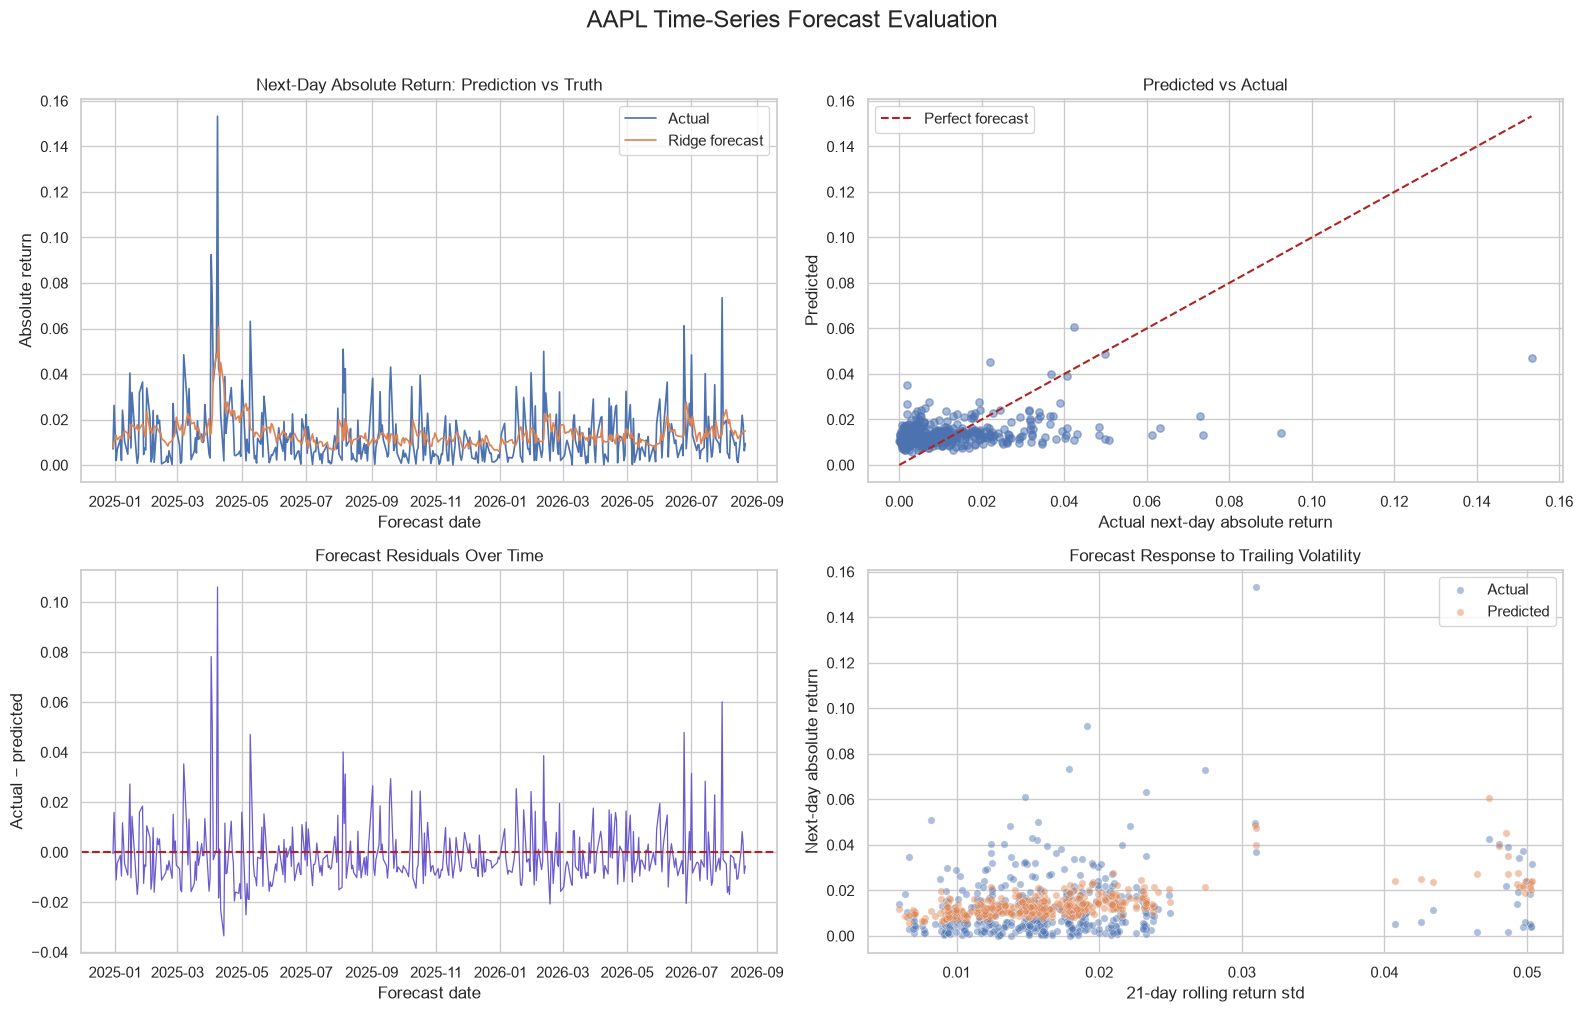

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(test['date'], y_test, label='Actual', linewidth=1.2)
axes[0, 0].plot(test['date'], test_predictions, label='Ridge forecast', linewidth=1.2)
axes[0, 0].set(title='Next-Day Absolute Return: Prediction vs Truth', xlabel='Forecast date', ylabel='Absolute return')
axes[0, 0].legend()

axes[0, 1].scatter(y_test, test_predictions, alpha=0.5, s=28)
limit = max(float(y_test.max()), float(test_predictions.max()))
axes[0, 1].plot([0, limit], [0, limit], color='firebrick', linestyle='--', label='Perfect forecast')
axes[0, 1].set(title='Predicted vs Actual', xlabel='Actual next-day absolute return', ylabel='Predicted')
axes[0, 1].legend()

axes[1, 0].plot(test['date'], residuals, linewidth=0.9, color='slateblue')
axes[1, 0].axhline(0, color='firebrick', linestyle='--')
axes[1, 0].set(title='Forecast Residuals Over Time', xlabel='Forecast date', ylabel='Actual − predicted')

sns.scatterplot(x=test['rolling_std_21'], y=y_test, alpha=0.45, s=28, ax=axes[1, 1], label='Actual')
sns.scatterplot(x=test['rolling_std_21'], y=test_predictions, alpha=0.45, s=28, ax=axes[1, 1], label='Predicted')
axes[1, 1].set(title='Forecast Response to Trailing Volatility', xlabel='21-day rolling return std', ylabel='Next-day absolute return')

fig.suptitle('AAPL Time-Series Forecast Evaluation', fontsize=17, y=1.01)
fig.tight_layout()
plt.show()

## 6. Interpretation: what works, what fails, and where assumptions break

### What works

The time-aware Ridge pipeline achieves test MAE of approximately **0.00923** and RMSE of **0.01338**, equivalent to about 0.92 and 1.34 percentage points of absolute daily return. It improves on the training-mean baseline by roughly **9.1% in MAE** and **7.9% in RMSE**, and its test R² is about **0.144**. The best cross-validated alpha is 100, suggesting that regularization helps control correlated lag and rolling features. Actual/predicted correlation is about 0.39, so the features contain some forward-looking ranking information.

The chronological split and expanding `TimeSeriesSplit` are more credible than random sampling. Scaling occurs inside the Pipeline and therefore inside each training fold. Lag, rolling, momentum, and z-score variables use only observations available by the current close; only the label is shifted forward.

### What fails

The model substantially underpredicts extreme volatility. For the highest realized test observation, actual absolute return is about 15.33% while the forecast is only about 4.72%. MAE in the upper target quartile is about 0.01579, more than twice the approximately 0.00704 MAE for the lower 75%. This is a serious limitation for a risk stakeholder, because the most costly misses occur on the days the system is meant to flag.

Ridge predictions are unconstrained; none are negative in this test period, but negative volatility forecasts remain possible in another sample. Point metrics also hide asymmetric costs and regime-specific failure. Good average MAE does not establish calibrated uncertainty or safe tail behavior.

### Assumptions and next steps

The approach assumes relationships between recent return/range/volume history and next-day volatility are reasonably stable. Regime shifts, revised market data, unusual corporate events, and a small number of extreme days can break that assumption. Rolling features overlap and remain correlated despite regularization. The selected alpha is conditional on this training history and should be re-estimated in walk-forward evaluation.

I trust this as a **validated baseline**, not a production risk model. Next I would use repeated walk-forward backtests, compare tail-period MAE and threshold recall, add prediction intervals, test non-negative or log-target models, and compare nonlinear tree models. Model selection should prioritize performance during high-volatility periods rather than average error alone.